In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [36]:
data_path = Path('data/E_Commerce_Cleaned.csv')
df = pd.read_csv(data_path)

X = df.select_dtypes(include=['number', 'bool']).drop(columns=['CustomerID','Churn']) 
y = df['Churn']


classifier = joblib.load('../models/classifier_model.pkl')

y_pred = classifier.predict(X)

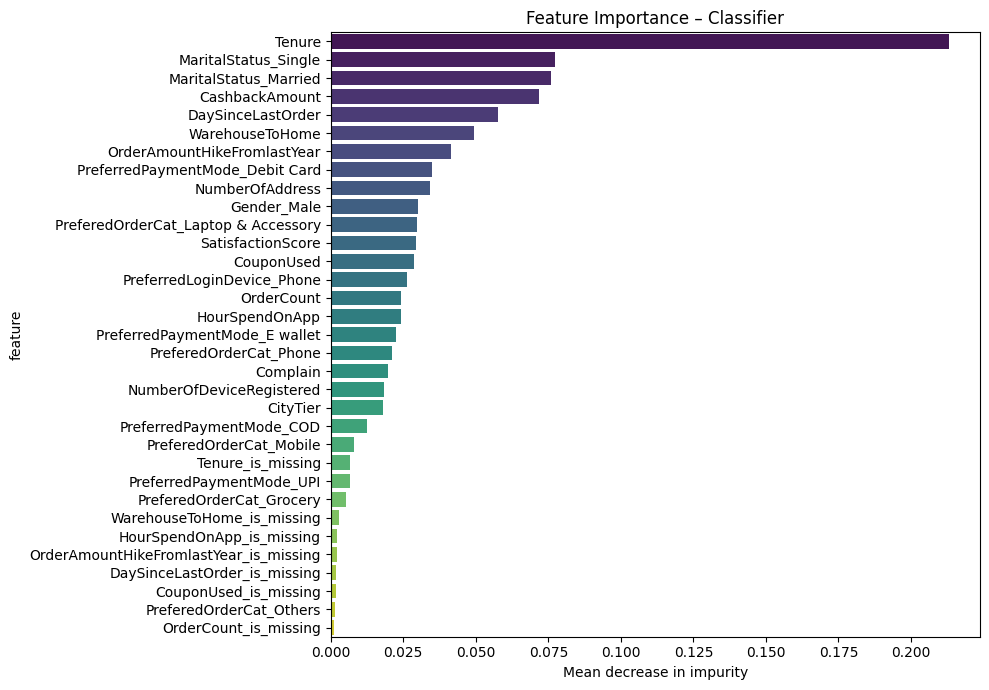

In [37]:

fi_df = (
    pd.DataFrame({'feature': X.columns, 'importance': classifier.feature_importances_})
    .sort_values('importance', ascending=False)
)
plt.figure(figsize=(10,7))
sns.barplot(data=fi_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('Feature Importance – Classifier')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()